# Standard Random Forest Classifier - Cancer Risk Dataset

This notebook trains a standard (non-private) Random Forest classifier on the Cancer Risk dataset to establish baseline performance.

## 1. Import Libraries

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


## 2. Load Preprocessed Data

In [2]:
with open('../data/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train = data['X_train']
X_test = data['X_test']
y_train = data['y_train']
y_test = data['y_test']
feature_names = data['feature_names']

print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"\nFeatures: {feature_names}")

Training data shape: (1200, 8)
Test data shape: (300, 8)
Number of features: 8

Features: ['Age', 'Gender', 'BMI', 'Smoking', 'GeneticRisk', 'PhysicalActivity', 'AlcoholIntake', 'CancerHistory']


## 3. Train Standard Random Forest Model

In [3]:
rf_model = RandomForestClassifier(
    n_estimators=20,
    max_depth=4,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Training Standard Random Forest...")
_t0 = time.perf_counter()
rf_model.fit(X_train, y_train)
train_time = time.perf_counter() - _t0
# Score the non-private fit on the training partition too, so the
# generalisation gap can be read next to the held-out metrics.
y_train_pred = rf_model.predict(X_train)
print("Training complete!")

Training Standard Random Forest...
Training complete!


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  20 out of  20 | elapsed:    0.1s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  20 out of  20 | elapsed:    0.0s finished


In [4]:
# Export model for MIA
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', '..')))
from model_exporter import export_model

export_model(rf_model, 'output/model/std_rf_model.pkl')

Model successfully exported to output/model/std_rf_model.pkl


## 4. Make Predictions

In [5]:
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)

print(f"Predictions shape: {y_pred.shape}")
print(f"Prediction probabilities shape: {y_pred_proba.shape}")

Predictions shape: (300,)
Prediction probabilities shape: (300, 2)


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  20 out of  20 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  20 out of  20 | elapsed:    0.0s finished


## 5. Model Evaluation

In [6]:
extra = ExtraMetrics()
accuracy = accuracy_score(y_test, y_pred)
extra.add(y_test, y_pred, model=rf_model, X=X_test, train_true=y_train, train_pred=y_train_pred, train_time=train_time)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("="*60)
print("STANDARD RANDOM FOREST - PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print("="*60)

STANDARD RANDOM FOREST - PERFORMANCE METRICS
Accuracy:  0.8500
F1-Score:  0.7594
Precision: 0.9342
Recall:    0.6396


[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  20 out of  20 | elapsed:    0.0s finished


## 6. Confusion Matrix

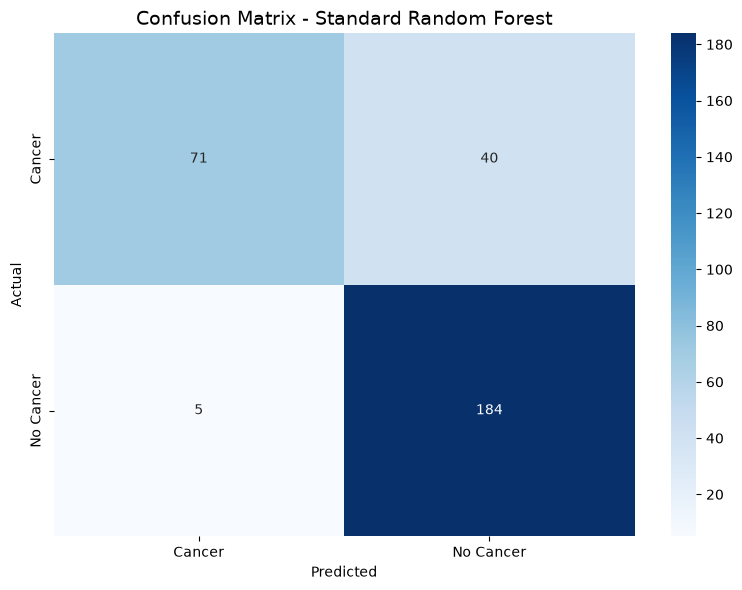


Confusion Matrix:
[[ 71  40]
 [  5 184]]

True Positives (TP): 71
False Negatives (FN): 40
False Positives (FP): 5
True Negatives (TN): 184


In [7]:
cm = confusion_matrix(y_test, y_pred)

TN = cm[0, 0]
FP = cm[0, 1]
FN = cm[1, 0]
TP = cm[1, 1]

custom_cm = np.array([
    [TP, FN],
    [FP, TN]
])

plt.figure(figsize=(8, 6))
sns.heatmap(custom_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cancer', 'No Cancer'],
            yticklabels=['Cancer', 'No Cancer'])
plt.title('Confusion Matrix - Standard Random Forest', fontsize=14)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(f"\nConfusion Matrix:")
print(custom_cm)
print(f"\nTrue Positives (TP): {TP}")
print(f"False Negatives (FN): {FN}")
print(f"False Positives (FP): {FP}")
print(f"True Negatives (TN): {TN}")

## 7. Classification Report

In [8]:
print("Classification Report:")
print(classification_report(y_test, y_pred, 
                          target_names=['No Cancer', 'Cancer']))

Classification Report:
              precision    recall  f1-score   support

   No Cancer       0.82      0.97      0.89       189
      Cancer       0.93      0.64      0.76       111

    accuracy                           0.85       300
   macro avg       0.88      0.81      0.83       300
weighted avg       0.86      0.85      0.84       300



## 8. Feature Importance

Feature Importances:
            feature  importance
7     CancerHistory    0.313691
4       GeneticRisk    0.163036
0               Age    0.112491
6     AlcoholIntake    0.109248
2               BMI    0.107021
1            Gender    0.102168
5  PhysicalActivity    0.051162
3           Smoking    0.041183


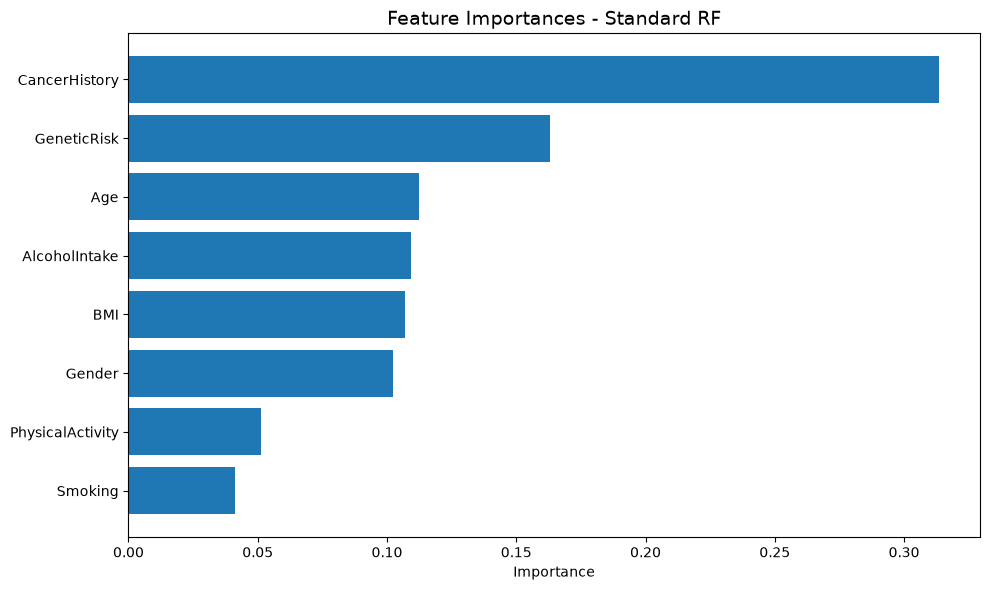

In [9]:
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Feature Importances:")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance_df)), feature_importance_df['importance'])
plt.yticks(range(len(feature_importance_df)), feature_importance_df['feature'])
plt.xlabel('Importance')
plt.title('Feature Importances - Standard RF', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Save Baseline Results

In [10]:
import os
os.makedirs('output', exist_ok=True)

baseline_results = pd.DataFrame({
    'model': ['Standard_RF'],
    'accuracy': [accuracy],
    'f1_score': [f1],
    'precision': [precision],
    'recall': [recall]
})

baseline_results.to_csv('output/baseline_results.csv', index=False)
print("Baseline results saved to 'output/baseline_results.csv'")

report = {
    'model_type': 'Standard Random Forest',
    'dataset': 'Cancer Risk Prediction',
    'parameters': {
        'n_estimators': 20,
        'max_depth': 4,
        'random_state': 42
    },
    'metrics': {
        'accuracy': float(accuracy),
        'f1_score': float(f1),
        'precision': float(precision),
        'recall': float(recall)
    },
    'confusion_matrix': custom_cm.tolist(),
    'feature_importance': feature_importance_df.to_dict('records')
}
report.update(extra.means())

with open('output/std_rf_report.json', 'w') as f:
    json.dump(report, f, indent=4)

print("Detailed report saved to 'output/std_rf_report.json'")

print("Added metrics:")
print(extra.describe())

Baseline results saved to 'output/baseline_results.csv'
Detailed report saved to 'output/std_rf_report.json'
Added metrics:
  Train Acc:      0.8600 ± 0.0000
  Balanced Acc:   0.8066 ± 0.0000
  AUROC:          0.9374 ± 0.0000
  Train Time (s): 0.0848 ± 0.0000


## 10. Summary

In [11]:
print("\n" + "="*60)
print("BASELINE MODEL SUMMARY")
print("="*60)
print(f"Model: Standard Random Forest")
print(f"Dataset: Cancer Risk Prediction ({X_train.shape[0]:,} train, {X_test.shape[0]:,} test)")
print(f"\nPerformance Metrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"\nBaseline established for DP comparison")
print("="*60)


BASELINE MODEL SUMMARY
Model: Standard Random Forest
Dataset: Cancer Risk Prediction (1,200 train, 300 test)

Performance Metrics:
  Accuracy:  0.8500
  F1-Score:  0.7594
  Precision: 0.9342
  Recall:    0.6396

Baseline established for DP comparison
